# Task 3 - Customer Segmentation
**Project:** Customer Churn Analysis and Prediction &nbsp;|&nbsp; **Organisation:** Saiket Systems - Data Analysis Internship
**Task:** Task 3 of 4 &nbsp;|&nbsp; **Prepared by:** [Your Name] &nbsp;|&nbsp; **Date:** October 2026
**Dataset:** Telco Customer Churn (7,043 customers, 21 columns)

**Objective.** Segment customers by tenure, monthly charges and contract type, then compare churn rates across the segments to find where the risk is concentrated.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
SEED = 42
PAL = {"No": "#4C78A8", "Yes": "#E45756"}

# Locate the project root whether this notebook sits in /notebooks or in the root folder
HERE = Path.cwd()
ROOT = next((p for p in [HERE, HERE.parent] if (p / "data" / "raw").exists()), HERE)
RAW = ROOT / "data" / "raw" / "Telco_Customer_Churn_Dataset_.csv"
PROCESSED = ROOT / "data" / "processed"; PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES = ROOT / "outputs" / "figures"; FIGURES.mkdir(parents=True, exist_ok=True)
TABLES = ROOT / "outputs" / "tables"; TABLES.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.savefig(FIGURES / name, dpi=150, bbox_inches="tight")

print("Project root:", ROOT)

Project root: /home/claude/telco-churn-project


In [2]:
CLEAN = PROCESSED / "telco_churn_cleaned.csv"
assert CLEAN.exists(), "Cleaned data not found - run Notebook 01 (data cleaning) first."
df = pd.read_csv(CLEAN)
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)
print("Loaded cleaned data:", df.shape)

Loaded cleaned data: (7043, 22)


## 1. Segmentation approach
| Dimension | Segments | Rationale |
|---|---|---|
| Tenure | New (0-12m), Developing (13-24m), Established (25-48m), Loyal (49-72m) | Business-meaningful lifecycle stages; Notebook 02 showed year 1 is the critical window |
| Monthly charges | Low / Medium / High (equal-sized terciles) | Terciles give equal group sizes, so churn rates are comparable |
| Contract | Month-to-month / One year / Two year | Existing categories |

In [3]:
seg = df.copy()
seg["TenureSegment"] = pd.cut(seg.tenure, [-1, 12, 24, 48, 72],
                              labels=["New (0-12m)", "Developing (13-24m)", "Established (25-48m)", "Loyal (49-72m)"])
seg["ChargeSegment"] = pd.qcut(seg.MonthlyCharges, 3, labels=["Low", "Medium", "High"])
print("Monthly-charge tercile cut points ($):", seg.MonthlyCharges.quantile([1/3, 2/3]).round(2).tolist())

def seg_table(col):
    return seg.groupby(col, observed=True).agg(
        customers=("ChurnFlag", "size"), churned=("ChurnFlag", "sum"),
        churn_rate_pct=("ChurnFlag", lambda s: round(s.mean() * 100, 1)))

for c in ["TenureSegment", "ChargeSegment", "Contract"]:
    display(seg_table(c))

Monthly-charge tercile cut points ($): [50.4, 83.9]


,customers,churned,churn_rate_pct
TenureSegment,,,
New (0-12m),2186,1037,47.4
Developing (13-24m),1024,294,28.7
Established (25-48m),1594,325,20.4
Loyal (49-72m),2239,213,9.5


,customers,churned,churn_rate_pct
ChargeSegment,,,
Low,2351,373,15.9
Medium,2345,696,29.7
High,2347,800,34.1


,customers,churned,churn_rate_pct
Contract,,,
Month-to-month,3875,1655,42.7
One year,1473,166,11.3
Two year,1695,48,2.8


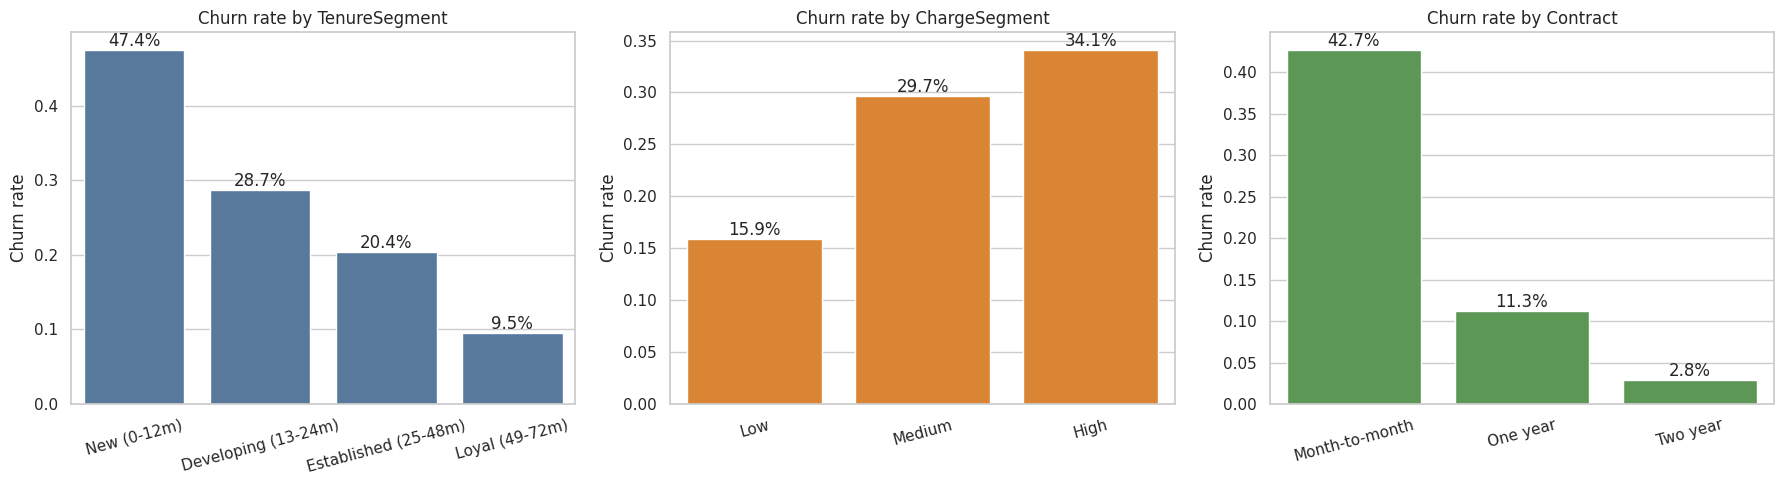

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for a, (col, colr) in zip(axes, [("TenureSegment", "#4C78A8"), ("ChargeSegment", "#F58518"), ("Contract", "#54A24B")]):
    sns.barplot(data=seg, x=col, y="ChurnFlag", errorbar=None, color=colr, ax=a)
    a.set_title(f"Churn rate by {col}"); a.set_ylabel("Churn rate"); a.set_xlabel(""); a.tick_params(axis="x", rotation=15)
    for p in a.patches:
        a.annotate(f"{p.get_height():.1%}", (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom")
plt.tight_layout(); savefig("seg_01_single_dimension.png"); plt.show()

**Findings (one dimension at a time)**
* **Tenure:** churn falls steadily with tenure, from 47.4% (new) to 28.7%, 20.4% and 9.5% (loyal).
* **Charges:** churn rises with price, from 15.9% (low) to 29.7% (medium) and 34.1% (high). The cut points are $50.40 and $83.90.
* **Contract:** 42.7% / 11.3% / 2.8% for month-to-month, one-year and two-year.

## 2. Combining the dimensions

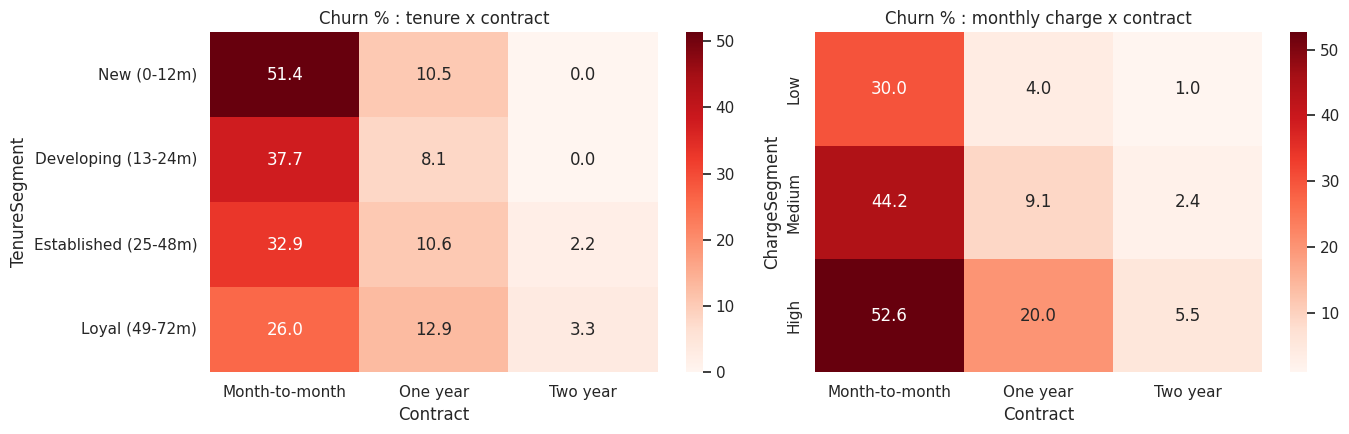

In [5]:
p1 = seg.pivot_table(index="TenureSegment", columns="Contract", values="ChurnFlag", aggfunc="mean", observed=True) * 100
p2 = seg.pivot_table(index="ChargeSegment", columns="Contract", values="ChurnFlag", aggfunc="mean", observed=True) * 100
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.heatmap(p1, annot=True, fmt=".1f", cmap="Reds", ax=axes[0]); axes[0].set_title("Churn % : tenure x contract")
sns.heatmap(p2, annot=True, fmt=".1f", cmap="Reds", ax=axes[1]); axes[1].set_title("Churn % : monthly charge x contract")
plt.tight_layout(); savefig("seg_02_heatmaps.png"); plt.show()

**Findings.** Contract dominates the picture. On a **two-year** contract churn stays at or below about 5.5% in every tenure and price segment. On **month-to-month** it ranges from 26% (loyal customers) to 52.6% (high-charge). Tenure helps month-to-month customers (51.4% new vs 26.0% loyal), but it does **not** make them safe.

In [6]:
seg["Segment"] = seg.TenureSegment.astype(str) + " | " + seg.ChargeSegment.astype(str) + " charge | " + seg.Contract
MIN_SIZE = 50   # ignore segments with fewer customers - their rates are unreliable
g = seg.groupby("Segment").agg(customers=("ChurnFlag", "size"), churned=("ChurnFlag", "sum"),
                               churn_rate_pct=("ChurnFlag", lambda s: s.mean() * 100)).round(1)
g = g[g.customers >= MIN_SIZE].sort_values("churn_rate_pct", ascending=False)
g.to_csv(TABLES / "segment_churn_table.csv")
pd.set_option("display.max_colwidth", 80)
print("Riskiest segments"); display(g.head(8))
print("Safest segments");   display(g.tail(5))

Riskiest segments


,customers,churned,churn_rate_pct
Segment,,,
New (0-12m) | High charge | Month-to-month,370,276,74.6
New (0-12m) | Medium charge | Month-to-month,824,461,55.9
Developing (13-24m) | High charge | Month-to-month,273,147,53.8
Established (25-48m) | High charge | Month-to-month,395,172,43.5
New (0-12m) | Low charge | Month-to-month,800,287,35.9
Developing (13-24m) | Medium charge | Month-to-month,285,97,34.0
Loyal (49-72m) | High charge | Month-to-month,226,70,31.0
Established (25-48m) | Medium charge | Month-to-month,263,72,27.4


Safest segments


,customers,churned,churn_rate_pct
Segment,,,
Loyal (49-72m) | Medium charge | Two year,334,8,2.4
Loyal (49-72m) | Low charge | Two year,409,5,1.2
Established (25-48m) | Low charge | Two year,175,2,1.1
Developing (13-24m) | Low charge | Two year,73,0,0.0
New (0-12m) | Low charge | Two year,56,0,0.0


In [7]:
# How much of total churn sits in the riskiest segments?
risky = ["New (0-12m) | High charge | Month-to-month", "New (0-12m) | Medium charge | Month-to-month",
         "New (0-12m) | Low charge | Month-to-month", "Developing (13-24m) | High charge | Month-to-month"]
sub = seg[seg.Segment.isin(risky)]
print(f"Top risky segments: {len(sub):,} customers ({len(sub)/len(seg):.1%} of base) "
      f"-> {sub.ChurnFlag.sum():,} churners = {sub.ChurnFlag.sum()/seg.ChurnFlag.sum():.1%} of all churn")

Top risky segments: 2,267 customers (32.2% of base) -> 1,171 churners = 62.7% of all churn


**Findings.** The worst segment is **new, high-charge, month-to-month customers: 74.6% churn** (370 customers). Almost every segment with churn above 35% is month-to-month. The safest segments (two-year contracts with low or medium charges) churn at about 0-2.4%. Note that segments with fewer than 50 customers are excluded, since their rates are unreliable. The four riskiest month-to-month segments listed above hold **32% of customers but 63% of all churners**, so the risk is highly concentrated.

## 3. RFM-style value tiers
Classic RFM (Recency, Frequency, Monetary) needs transaction dates, which this dataset does not have. The closest available proxies are used instead:

| RFM idea | Proxy used |
|---|---|
| Recency / loyalty | `tenure` |
| Monetary value | `TotalCharges` (lifetime spend) |
| Frequency / engagement | Number of services subscribed |

Each is scored 1-3 (terciles) and summed into a 3-9 score, then grouped into Low (3-4), Mid (5-6) and High (7-9) value.

In [8]:
svc = ["PhoneService"] + ["MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
                          "TechSupport", "StreamingTV", "StreamingMovies"]
seg["NumServices"] = (seg[svc] == "Yes").sum(axis=1) + (seg.InternetService != "No").astype(int)
for name, col in [("T_score", "tenure"), ("M_score", "TotalCharges"), ("S_score", "NumServices")]:
    seg[name] = pd.qcut(seg[col].rank(method="first"), 3, labels=[1, 2, 3]).astype(int)
seg["RFM_total"] = seg[["T_score", "M_score", "S_score"]].sum(axis=1)
seg["Value_Tier"] = pd.cut(seg.RFM_total, [2, 4, 6, 9], labels=["Low value", "Mid value", "High value"])

tier = seg.groupby("Value_Tier", observed=True).agg(
    customers=("ChurnFlag", "size"), avg_monthly=("MonthlyCharges", "mean"),
    avg_tenure=("tenure", "mean"), churn_rate_pct=("ChurnFlag", lambda s: s.mean() * 100)).round(1)
tier.to_csv(TABLES / "rfm_value_tiers.csv")
tier

,customers,avg_monthly,avg_tenure,churn_rate_pct
Value_Tier,,,,
Low value,2253,45.9,7.0,38.8
Mid value,2051,55.1,32.4,25.1
High value,2739,87.5,53.2,17.5


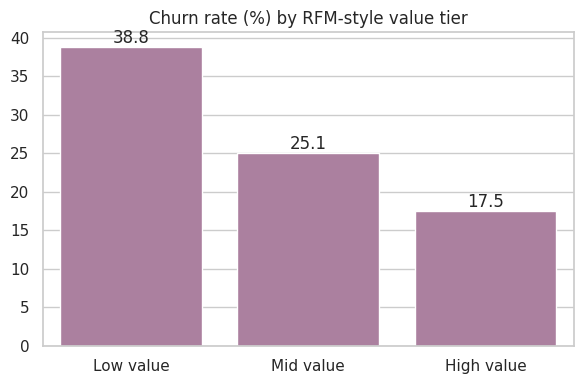

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
r = tier.churn_rate_pct
sns.barplot(x=r.index, y=r.values, color="#B279A2", ax=ax); ax.set_title("Churn rate (%) by RFM-style value tier"); ax.set_xlabel("")
for p in ax.patches: ax.annotate(f"{p.get_height():.1f}", (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom")
plt.tight_layout(); savefig("seg_03_value_tiers.png"); plt.show()

**Findings.** "High value" customers (long tenure, high lifetime spend, many services) churn at only 17.5%, while "Low value" customers churn at 38.8%. Because this score is built partly from tenure, part of that gap is the tenure effect already seen above. The tiers are best used to prioritise, for example to see how many high-value customers are still at risk.

## Summary of Task 3
| Segment | Churn rate |
|---|---|
| New customers (0-12 months) | 47.4% |
| Loyal customers (49-72 months) | 9.5% |
| High monthly charge | 34.1% |
| Low monthly charge | 15.9% |
| Month-to-month | 42.7% |
| Two-year | 2.8% |
| **New + high charge + month-to-month** | **74.6%** |
| Two-year, any tenure or price | 0-5.5% |

**Implication.** Churn is concentrated, not spread evenly. A retention programme can focus on a small number of segments, mainly **month-to-month customers in their first year**, instead of the whole base.